# K-Means 聚类：从直觉到实战

想象你是一个活动策划师，手里有一堆用户画像数据，但没有人告诉你“谁属于哪一类”。

这就是**无监督学习**的典型场景：
- 没有标签（不知道标准答案）
- 希望自动发现数据里的“自然分组”

K-Means 是最经典、最常用、最容易上手的聚类算法之一。这个笔记本会带你：
1. 用直觉理解 K-Means 在做什么
2. 看懂它优化的数学目标
3. 手写一个 K-Means（理解本质）
4. 用 sklearn 高效实战
5. 学会选择 K 值（肘部法 + 轮廓系数）
6. 了解常见坑与最佳实践

## 1. 先准备环境

我们会使用：
- numpy：数值计算
- matplotlib：可视化
- seaborn：更好看的图形风格
- sklearn：生成数据、标准化、KMeans、评估指标

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", context="talk")

# 配置中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

print("环境准备完成")

环境准备完成


## 2. K-Means 的直觉

可以把 K-Means 想成“找 K 个营地，让每个点去最近的营地报到”：
1. 随机放置 K 个中心点（营地）
2. 每个样本分配给最近的中心
3. 每个簇重新计算中心（取均值）
4. 重复 2-3，直到中心几乎不再变化

这个过程会让同一簇内的点越来越紧凑。

/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/

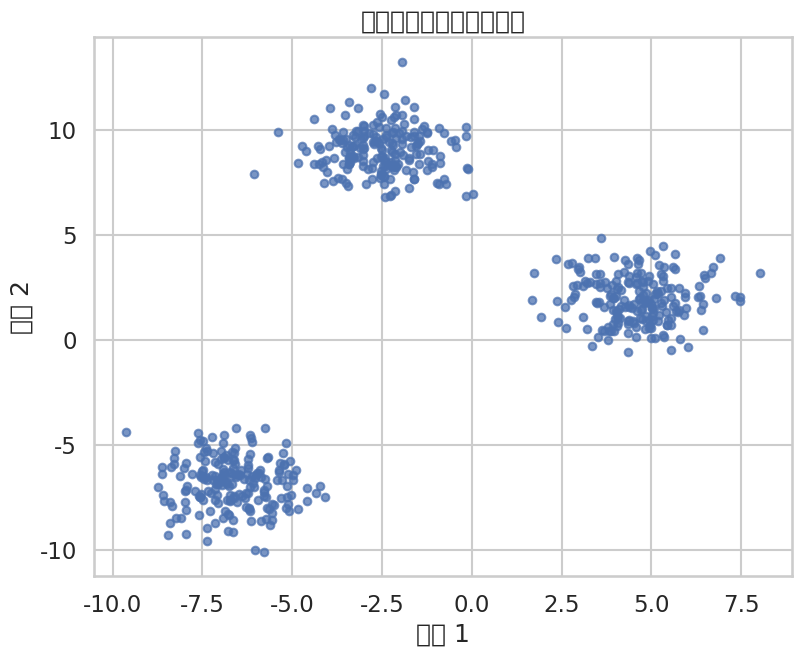

In [9]:
# 构造一个三簇数据集（二维，便于画图）
X, y_true = make_blobs(
    n_samples=600,
    centers=3,
    cluster_std=1.1,
    random_state=42
)

plt.figure(figsize=(9, 7))
plt.scatter(X[:, 0], X[:, 1], s=30, alpha=0.75)
plt.title("原始数据（无标签视角）")
plt.xlabel("特征 1")
plt.ylabel("特征 2")
plt.show()

## 3. K-Means 在优化什么？

K-Means 的目标是最小化簇内平方和（Inertia / WCSS）：

$$
J = \sum_{j=1}^{K} \sum_{x_i \in C_j} \|x_i - \mu_j\|^2
$$

其中：
- $C_j$ 是第 $j$ 个簇 , $$C_j = \{x_i : \text{第 } i \text{ 个样本属于第 } j \text{ 个簇}\}$$
- $\mu_j$ 是第 $j$ 个簇的中心（均值）
- 距离通常使用欧氏距离

**数学推导过程：**

1. **欧氏距离的平方展开**
   
   $$\|x_i - \mu_j\|^2 = (x_i - \mu_j)^T(x_i - \mu_j) = \|x_i\|^2 - 2x_i^T\mu_j + \|\mu_j\|^2$$

2. **对目标函数求和**
   
   $$J = \sum_{j=1}^{K} \sum_{x_i \in C_j} \left(\|x_i\|^2 - 2x_i^T\mu_j + \|\mu_j\|^2\right)$$

3. **最优中心的推导**
   
   对 $\mu_j$ 求偏导并令其为零：
   
   $$\frac{\partial J}{\partial \mu_j} = \sum_{x_i \in C_j} (-2x_i + 2\mu_j) = 0$$
   
   得到：
   
   $$\mu_j = \frac{1}{|C_j|}\sum_{x_i \in C_j} x_i$$
   
   即簇的中心就是该簇内所有点的**算术平均值**。

4. **收敛性**
   
   每次更新必然使 $J$ 不增加（单调性），且由于 $J$ 有下界，算法最终收敛到局部最优。

**直观理解：** 直观上，$J$ 越小，说明每个簇内部越"紧凑"。算法通过"分配 + 更新中心"的迭代，逐步让簇内的点靠得更近。

> **注意：** K-Means 追求的是"球状、大小相近"的簇。如果数据存在月牙形、环形等非凸形状，K-Means 往往效果不佳。

## 4. 手写一个 K-Means（看清算法本质）

In [10]:
def kmeans_from_scratch(X, k=3, max_iter=100, tol=1e-4, random_state=42):
    rng = np.random.default_rng(random_state)

    # 1) 随机选择 k 个初始中心
    init_idx = rng.choice(len(X), size=k, replace=False)
    centers = X[init_idx].astype(float)

    history = [centers.copy()]
    labels = None

    for _ in range(max_iter):
        # 2) 计算每个点到各中心的距离并分配簇
        # distances 形状: (n_samples, k)
        distances = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
        labels = np.argmin(distances, axis=1)

        # 3) 更新中心（取各簇均值）
        new_centers = np.array([
            X[labels == i].mean(axis=0) if np.any(labels == i) else centers[i]
            for i in range(k)
        ])

        history.append(new_centers.copy())

        # 4) 收敛判定
        # 计算新旧中心的移动距离（欧氏范数）
        # np.linalg.norm() 默认计算 L2 范数（欧氏距离）
        # 结果是一个标量，表示所有中心点的总位移
        shift = np.linalg.norm(new_centers - centers)
        centers = new_centers
        if shift < tol:
            break

    # 计算 inertia（簇内平方和）
    inertia = np.sum((X - centers[labels]) ** 2)
    return labels, centers, inertia, history

labels_manual, centers_manual, inertia_manual, history = kmeans_from_scratch(X, k=3)
print(f"手写 K-Means 收敛迭代次数: {len(history) - 1}")
print(f"手写 K-Means inertia: {inertia_manual:.2f}")

手写 K-Means 收敛迭代次数: 12
手写 K-Means inertia: 11322.12


/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32858 (\N{CJK UNIFIED IDEOGRAPH-805A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/

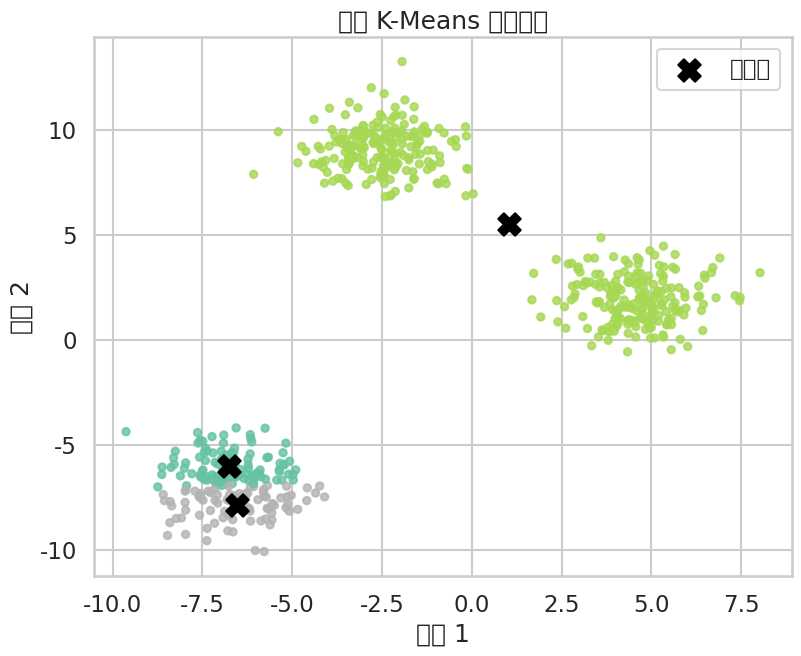

/tmp/ipykernel_22331/2430299110.py:37: UserWarning: Glyph 21021 (\N{CJK UNIFIED IDEOGRAPH-521D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/2430299110.py:37: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/2430299110.py:37: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/2430299110.py:37: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/2430299110.py:37: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/2430299110.py:37: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/2430299110.py:37: UserWarning: Glyph 36845 (\N{CJK UNIFIED IDEOGRAP

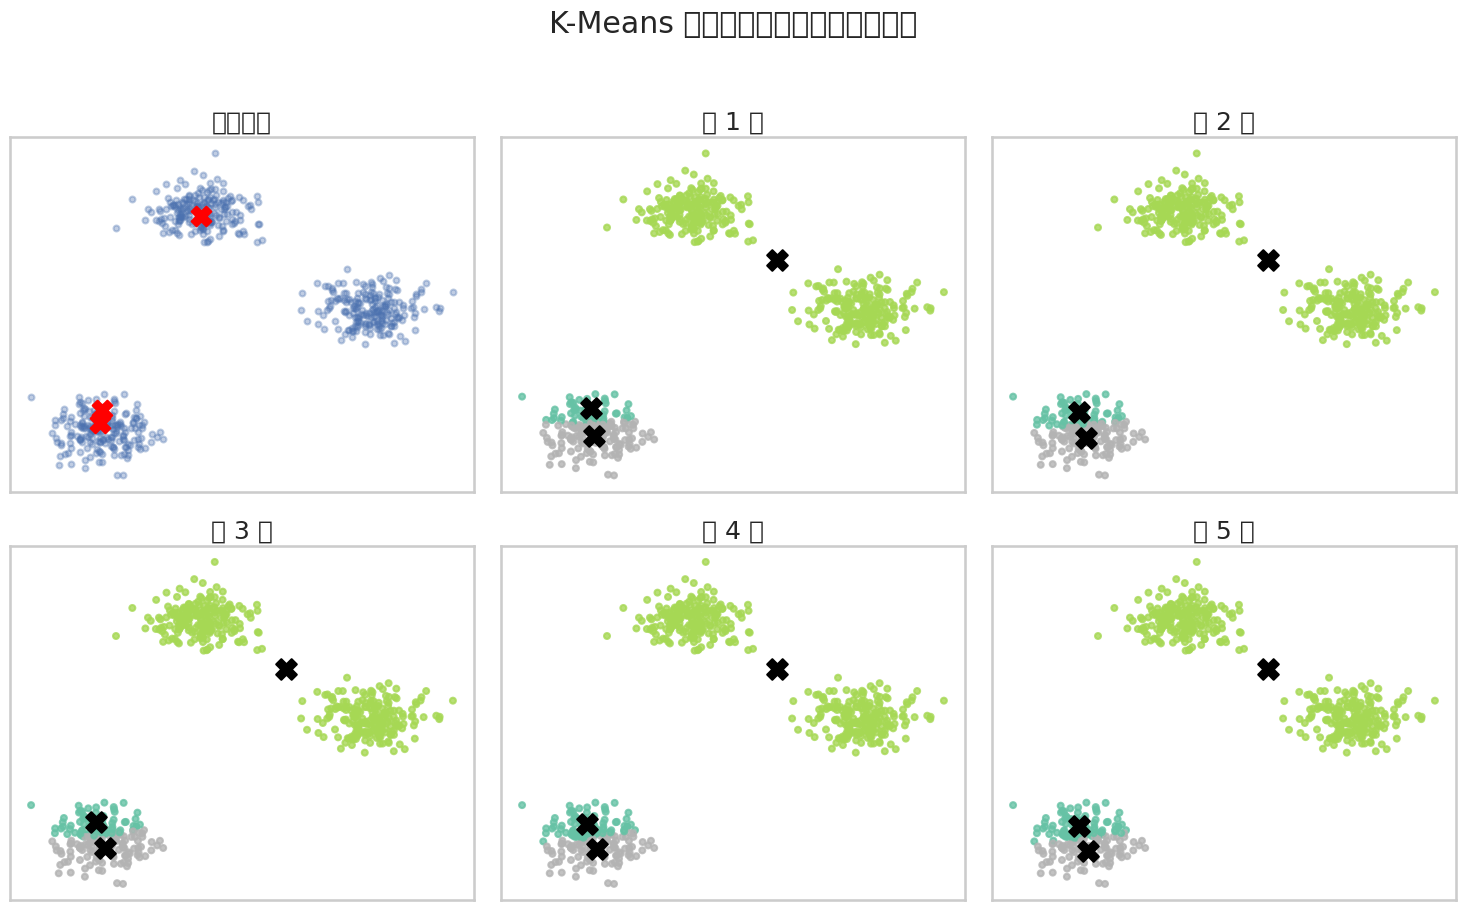

In [11]:
# 可视化：最终聚类结果 + 中心点
plt.figure(figsize=(9, 7))
plt.scatter(X[:, 0], X[:, 1], c=labels_manual, cmap="Set2", s=28, alpha=0.8)
plt.scatter(centers_manual[:, 0], centers_manual[:, 1], c="black", s=260, marker="X", label="中心点")
plt.title("手写 K-Means 聚类结果")
plt.xlabel("特征 1")
plt.ylabel("特征 2")
plt.legend()
plt.show()

# 可视化：中心点如何移动（前几轮）
show_steps = min(6, len(history))
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for i in range(show_steps):
    ax = axes[i]
    if i == 0:
        ax.scatter(X[:, 0], X[:, 1], s=18, alpha=0.35)
        ax.scatter(history[i][:, 0], history[i][:, 1], c="red", s=200, marker="X")
        ax.set_title("初始中心")
    else:
        temp_centers = history[i]
        temp_dist = np.linalg.norm(X[:, None, :] - temp_centers[None, :, :], axis=2)
        temp_labels = np.argmin(temp_dist, axis=1)
        ax.scatter(X[:, 0], X[:, 1], c=temp_labels, cmap="Set2", s=18, alpha=0.8)
        ax.scatter(temp_centers[:, 0], temp_centers[:, 1], c="black", s=220, marker="X")
        ax.set_title(f"第 {i} 轮")

    ax.set_xticks([])
    ax.set_yticks([])

for j in range(show_steps, 6):
    axes[j].axis("off")

plt.suptitle("K-Means 迭代过程（中心点逐步稳定）", y=1.02)
plt.tight_layout()
plt.show()

## 5. sklearn 版本：工业级常用写法

在实际项目里，我们更常用 sklearn 的 `KMeans`：
- 更稳定（支持多次初始化）
- 代码更简洁
- 便于与整个机器学习流程衔接

/tmp/ipykernel_22331/1144315242.py:23: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/1144315242.py:23: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/1144315242.py:23: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/1144315242.py:23: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


sklearn KMeans inertia: 1404.69


/tmp/ipykernel_22331/1144315242.py:23: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/1144315242.py:23: UserWarning: Glyph 29616 (\N{CJK UNIFIED IDEOGRAPH-73B0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/1144315242.py:23: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/1144315242.py:23: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/1144315242.py:23: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/1144315242.py:23: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/py

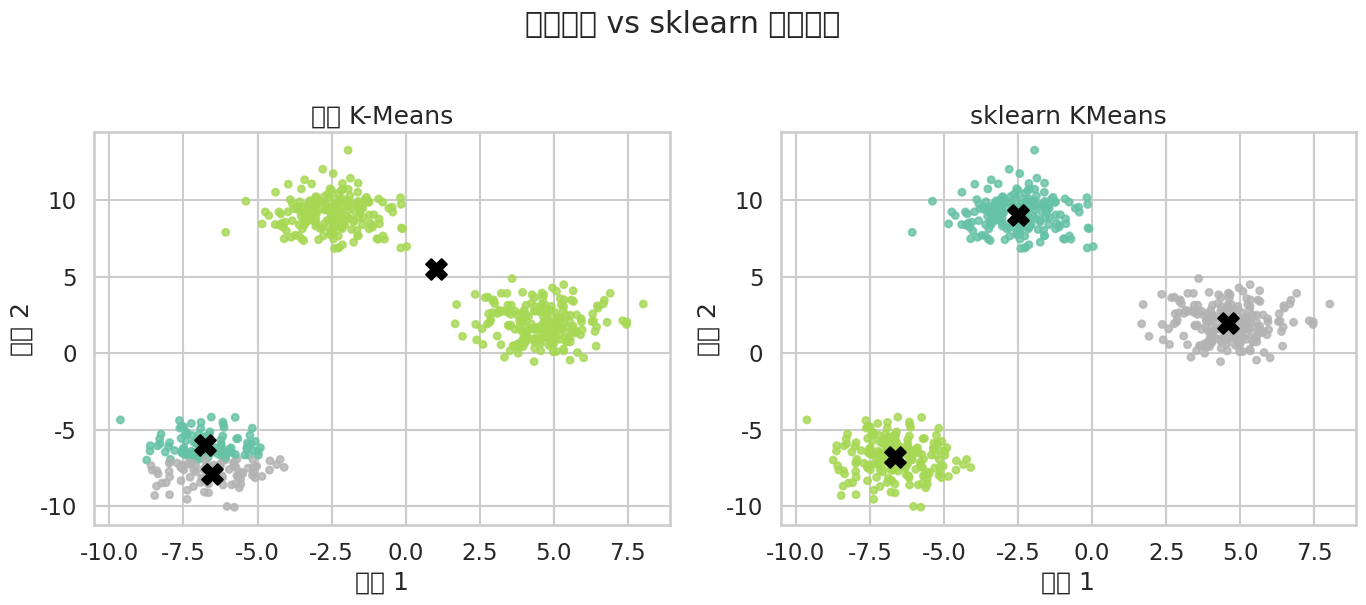

In [12]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_sklearn = kmeans.fit_predict(X)
centers_sklearn = kmeans.cluster_centers_
inertia_sklearn = kmeans.inertia_

print(f"sklearn KMeans inertia: {inertia_sklearn:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X[:, 0], X[:, 1], c=labels_manual, cmap="Set2", s=24, alpha=0.8)
axes[0].scatter(centers_manual[:, 0], centers_manual[:, 1], c="black", s=220, marker="X")
axes[0].set_title("手写 K-Means")

axes[1].scatter(X[:, 0], X[:, 1], c=labels_sklearn, cmap="Set2", s=24, alpha=0.8)
axes[1].scatter(centers_sklearn[:, 0], centers_sklearn[:, 1], c="black", s=220, marker="X")
axes[1].set_title("sklearn KMeans")

for ax in axes:
    ax.set_xlabel("特征 1")
    ax.set_ylabel("特征 2")

plt.suptitle("手写实现 vs sklearn 结果对比", y=1.02)
plt.tight_layout()
plt.show()

## 6. K 值怎么选？

K 是 K-Means 的灵魂参数，常见做法：
- 肘部法（Elbow Method）：看 inertia 随 K 增加的下降拐点
- 轮廓系数（Silhouette Score）：越接近 1 表示聚类越清晰

通常两者结合，再加业务理解来确定 K。

/tmp/ipykernel_22331/926883663.py:23: UserWarning: Glyph 32920 (\N{CJK UNIFIED IDEOGRAPH-8098}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/926883663.py:23: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/926883663.py:23: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/926883663.py:23: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/926883663.py:23: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/926883663.py:23: UserWarning: Glyph 24275 (\N{CJK UNIFIED IDEOGRAPH-5ED3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/926883663.py:23: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing f

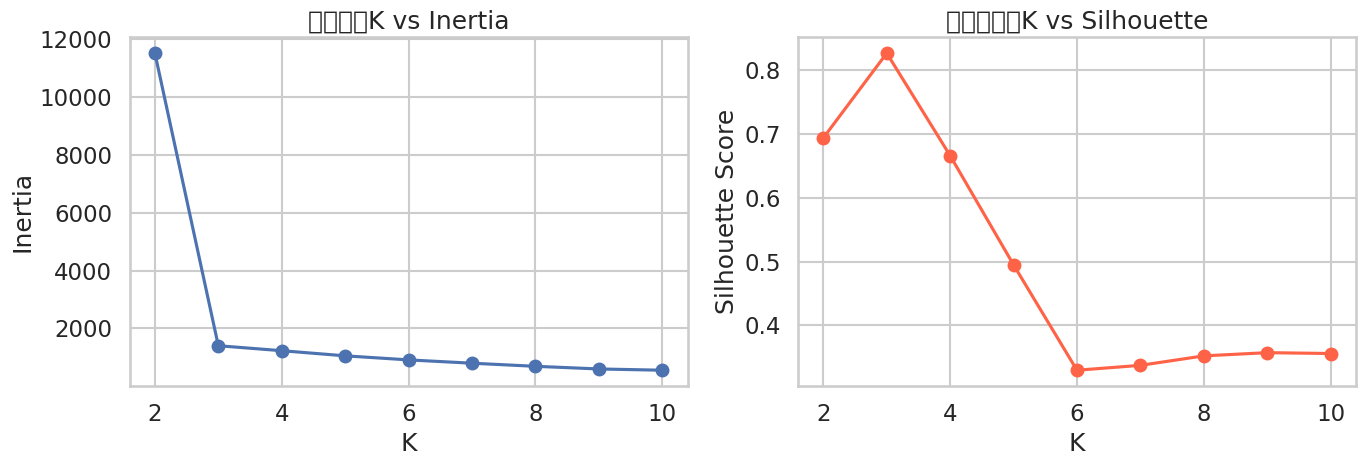

轮廓系数建议 K = 3


In [13]:
k_values = range(2, 11)
inertias = []
sil_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_k = model.fit_predict(X)
    inertias.append(model.inertia_)
    sil_scores.append(silhouette_score(X, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_values), inertias, marker="o")
axes[0].set_title("肘部法：K vs Inertia")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_values), sil_scores, marker="o", color="tomato")
axes[1].set_title("轮廓系数：K vs Silhouette")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

best_k_by_silhouette = list(k_values)[int(np.argmax(sil_scores))]
print(f"轮廓系数建议 K = {best_k_by_silhouette}")

## 7. 一个非常关键的细节：特征缩放

K-Means 基于距离计算，如果特征量纲差异很大，大尺度特征会“主导距离”。

下面做一个对比：
- 未标准化：直接聚类
- 标准化后：再聚类

你会看到聚类边界和中心位置会明显变化。

/tmp/ipykernel_22331/2096525901.py:35: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/2096525901.py:35: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/2096525901.py:35: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/2096525901.py:35: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/2096525901.py:35: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/2096525901.py:35: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/2096525901.py:35: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAP

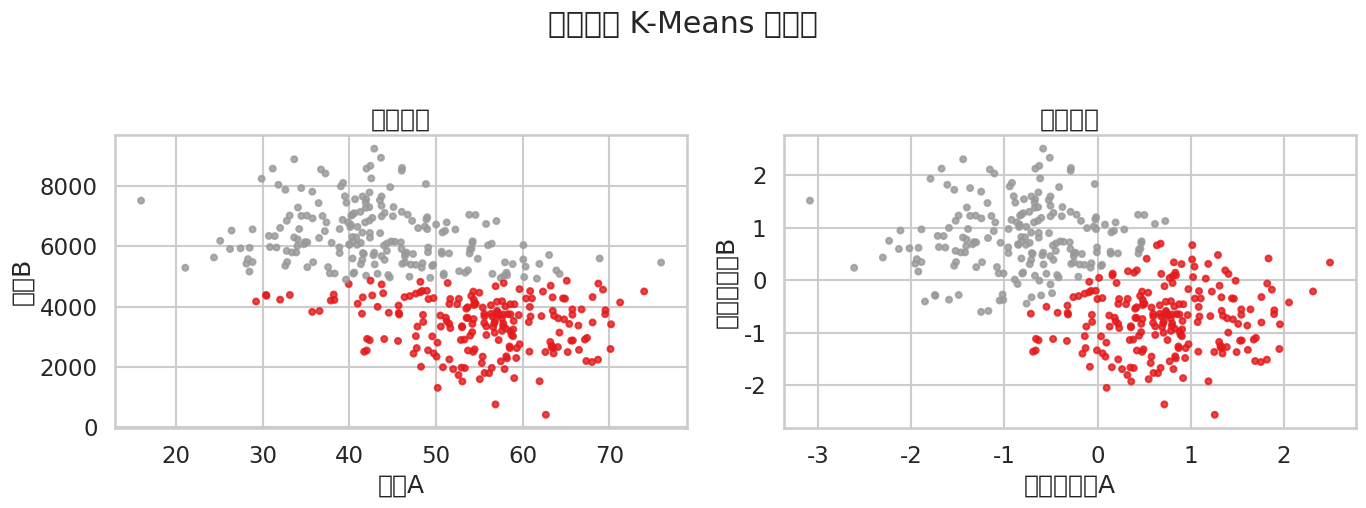

In [14]:
# 构造量纲差异明显的数据
rng = np.random.default_rng(7)
X_scale_demo = np.column_stack([
    rng.normal(loc=50, scale=8, size=400),      # 特征A：范围较小
    rng.normal(loc=5000, scale=1200, size=400)  # 特征B：范围巨大
])

# 人为加入两类中心偏移
X_scale_demo[:200] += np.array([8, -1200])
X_scale_demo[200:] += np.array([-8, 1200])

# 未标准化
km_raw = KMeans(n_clusters=2, n_init=10, random_state=42)
labels_raw = km_raw.fit_predict(X_scale_demo)

# 标准化后
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_scale_demo)
km_scaled = KMeans(n_clusters=2, n_init=10, random_state=42)
labels_scaled = km_scaled.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_scale_demo[:, 0], X_scale_demo[:, 1], c=labels_raw, cmap="Set1", s=18, alpha=0.8)
axes[0].set_title("未标准化")
axes[0].set_xlabel("特征A")
axes[0].set_ylabel("特征B")

axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_scaled, cmap="Set1", s=18, alpha=0.8)
axes[1].set_title("标准化后")
axes[1].set_xlabel("标准化特征A")
axes[1].set_ylabel("标准化特征B")

plt.suptitle("标准化对 K-Means 的影响", y=1.03)
plt.tight_layout()
plt.show()

## 8. K-Means 优缺点速览

优点：
- 思想简单，训练速度快
- 在“球状簇”场景效果好
- 可解释性强（每个簇有中心）

局限：
- 需要事先指定 K
- 对初始中心敏感（可用 `n_init` 缓解）
- 对异常值敏感
- 不擅长处理非凸形状簇（如月牙）

适用场景：
- 用户分群（人群画像）
- 商品分组
- 图像颜色量化
- 异常检测前的粗分组

## 9. 小结

一句话总结：

**K-Means = 在给定 K 的前提下，让每个簇内样本尽量靠近自己的中心点。**

你现在应该已经掌握：
- K-Means 的核心机制（分配 + 更新）
- 目标函数（最小化簇内平方和）
- 手写实现与 sklearn 使用
- K 值选择方法
- 标准化的重要性

---

## 10. 动手练习（建议）

1. 把 `centers=3` 改成 `centers=4`，再用肘部法和轮廓系数判断最佳 K。
2. 调整 `cluster_std`（比如 0.5、2.0、3.0），观察聚类难度变化。
3. 在你的真实数据上试一次：先标准化，再比较不同 K 的结果。
4. 尝试对比 DBSCAN，体会它在非球状簇上的优势。

## 11. 重要澄清：K-Means 中点和中心的关系

一个很容易混淆的点：**数据点位置永不变化，只有中心点在迭代移动**。

K-Means 的步骤是：
1. **数据点** → 位置固定，是输入数据
2. **中心点** → 初始化后不断更新（迭代移动）
3. **簇分配** → 每轮根据"点到新中心的距离"重新分配簇

**类比：** 
- 数据点 = 固定的城市
- 中心点 = 流动的物流配送中心
- 每轮迭代 = 配送中心搬家，影响哪些城市归属哪个中心

/tmp/ipykernel_22331/1542542488.py:84: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/1542542488.py:84: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/1542542488.py:84: UserWarning: Glyph 21021 (\N{CJK UNIFIED IDEOGRAPH-521D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/1542542488.py:84: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/1542542488.py:84: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/1542542488.py:84: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22331/1542542488.py:84: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) mi

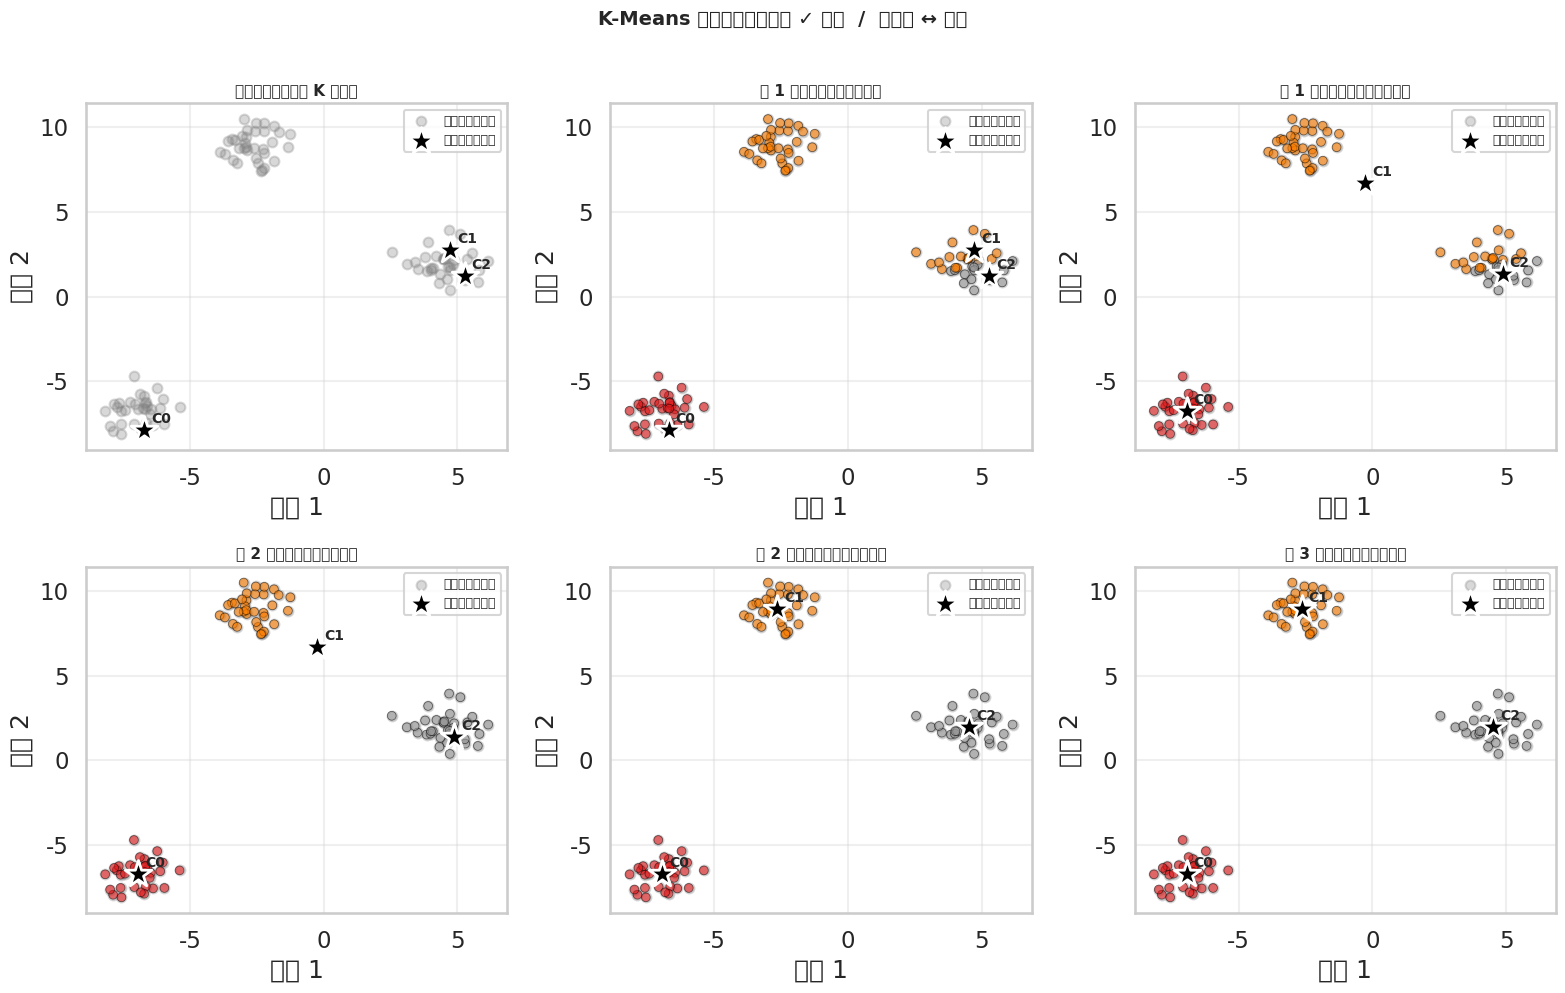

✓ 数据点位置：从始至终不变
✓ 中心点位置：每轮迭代都在更新
✓ 簇分配：根据点到最新中心的距离重新计算


In [15]:
"""
可视化展示：数据点固定，中心点移动
"""
# 重新生成数据（为了清晰，用更少的点）
X_demo, _ = make_blobs(n_samples=100, centers=3, cluster_std=0.8, random_state=42)

# 手工实现前 5 轮迭代，记录每一步
def kmeans_verbose(X, k=3, max_iter=5, random_state=42):
    rng = np.random.default_rng(random_state)
    init_idx = rng.choice(len(X), size=k, replace=False)
    centers = X[init_idx].astype(float)
    
    iterations = []
    iterations.append({
        'labels': None,  # 初始化前没有标签
        'centers': centers.copy(),
        'title': '初始化：随机选择 K 个中心'
    })
    
    for iter_num in range(max_iter):
        # 步骤 1: 计算距离并分配簇
        distances = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
        labels = np.argmin(distances, axis=1)
        
        iterations.append({
            'labels': labels.copy(),
            'centers': centers.copy(),
            'title': f'第 {iter_num + 1} 轮：分配点到最近中心'
        })
        
        # 步骤 2: 更新中心
        new_centers = np.array([
            X[labels == i].mean(axis=0) if np.any(labels == i) else centers[i]
            for i in range(k)
        ])
        
        iterations.append({
            'labels': labels.copy(),
            'centers': new_centers.copy(),
            'title': f'第 {iter_num + 1} 轮：更新中心到簇的均值'
        })
        
        centers = new_centers
    
    return iterations

# 生成迭代过程
iterations = kmeans_verbose(X_demo, k=3, max_iter=3)

# 绘制前 6 个关键步骤
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx in range(min(6, len(iterations))):
    ax = axes[idx]
    step = iterations[idx]
    
    # 所有数据点始终保持固定位置和灰色
    ax.scatter(X_demo[:, 0], X_demo[:, 1], s=50, alpha=0.3, color='gray', label='数据点（固定）')
    
    # 如果有标签分配，用颜色显示
    if step['labels'] is not None:
        scatter = ax.scatter(X_demo[:, 0], X_demo[:, 1], c=step['labels'], 
                            cmap='Set1', s=40, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # 中心点用大的星号标记
    ax.scatter(step['centers'][:, 0], step['centers'][:, 1], 
              c='black', s=400, marker='*', edgecolors='white', linewidth=2,
              label='中心点（移动）', zorder=10)
    
    # 标注中心点编号
    for i, center in enumerate(step['centers']):
        ax.annotate(f'C{i}', xy=center, fontsize=10, fontweight='bold',
                   xytext=(5, 5), textcoords='offset points')
    
    ax.set_title(step['title'], fontsize=11, fontweight='bold')
    ax.set_xlabel('特征 1')
    ax.set_ylabel('特征 2')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('K-Means 迭代过程：数据点 ✓ 固定  /  中心点 ↔ 移动', 
            fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✓ 数据点位置：从始至终不变")
print("✓ 中心点位置：每轮迭代都在更新")
print("✓ 簇分配：根据点到最新中心的距离重新计算")

## 核心概念对比表

| 对象 | 初始状态 | 迭代中 | 最终状态 | 作用 |
|------|--------|------|--------|------|
| **数据点 (X)** | 输入给定 | **保持不变** | **保持不变** | 被聚类的原始数据 |
| **中心点 (μ)** | 随机初始化 | **不断迭代移动** | 稳定 | 聚类的代表，决定分组 |
| **簇标签 (labels)** | 无 | **每轮重新计算** | 最终分配 | 表示点属于哪个簇 |

## 伪代码解读

```
初始化：
  中心点 = 随机选 K 个点

重复迭代：
  1️⃣ 分配点：
     for 每个数据点 x:
         x 的簇 = 距离最近的中心
     [点的位置 ❌ 不变]
  
  2️⃣ 更新中心：
     for 每个簇 j:
         中心[j] = 该簇所有点的平均位置
     [中心位置 ✓ 改变了]

直到：中心点移动距离很小（收敛）
```

所以你的直觉是对的：**中心点在不断变化，而点的位置一直是固定的。**